# 비트코인 안전자산 가설 검증 — 수정판 분석

> **원본 repo**: [`fbghkdrb/2026_capstone`](https://github.com/fbghkdrb/2026_capstone)
> **수정 phase**: critical 4건 (B1 GARCH 라이브러리 / B2+B3 경계수렴 / C1 윈도우 / A1 BTC 로직)
> **본 노트북**: 수정 결과를 한 화면에서 보여주는 공유용 자료

---

## 연구 질문
지정학적 위기 시 BTC 는 금처럼 **안전자산** 으로 기능하는가?

## 판정 기준 — Baur & Lucey (2010)
| 조건 | 정의 |
|---|---|
| ① CAR 양의 유의 | 위기 ±N일 BTC 누적초과수익 > 0, 통계적 유의 |
| ② 위기 시 상관 ≤ 0 | BTC ↔ SP500 상관계수가 위기 기간에 0 이하 |
| ③ 하락 분위에서 β < 0 | 분위회귀 τ ≤ 0.10 에서 SP500 회귀계수가 음의 유의 |

## 6 이벤트
1. 호르무즈 위기 (2019-06-13)
2. 솔레이마니 암살 (2020-01-03)
3. 러-우 전쟁 (2022-02-24)
4. 이스라엘-하마스 (2023-10-07)
5. 이스라엘-이란 충돌 (2024-04-01)
6. 미-이스라엘-이란 (2026-02-28)


---
## 1. 환경 설정 + 결과 데이터 로드

분석 결과 CSV 9개를 `_review/results/` 에서 로드. (스크립트 미실행 시 `_review/scripts/01~03.py` 먼저 실행)


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

REPO = '/mnt/d/project/2026_capstone'
R = f'{REPO}/_review/results'

# 한글 폰트 (가능한 경우)
for f in ['NanumGothic', 'AppleGothic', 'Malgun Gothic', 'DejaVu Sans']:
    try:
        rcParams['font.family'] = f
        break
    except Exception:
        continue
rcParams['axes.unicode_minus'] = False

# 데이터 로드
master = pd.read_csv(f'{REPO}/Edit_mj/master_data.csv')
master['date'] = pd.to_datetime(master['date'])

es      = pd.read_csv(f'{R}/event_study_sensitivity.csv')
g_arch  = pd.read_csv(f'{R}/garch_arch_lib.csv')
g_cmp_a = pd.read_csv(f'{R}/garch_arch_lib_compare.csv')
g_cust  = pd.read_csv(f'{R}/garch_custom_fixed.csv')
g_cmp_b = pd.read_csv(f'{R}/garch_custom_compare.csv')
btc_abl = pd.read_csv(f'{R}/btc_logic_ablation.csv')
btc_cmp = pd.read_csv(f'{R}/btc_returns_compare.csv')
btc_cmp['date'] = pd.to_datetime(btc_cmp['date'])

print(f'master_data: {len(master)}거래일 × {len(master.columns)}컬럼')
print(f'이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())


master_data: 216거래일 × 19컬럼
이벤트별 거래일:
event_name
hormuz_crisis              34
israel_hamas               38
israel_iran                37
russia_ukraine_invasion    35
soleimani_assassination    34
us_israel_iran             38


---
## 2. Phase 1 진단 — 팀원 원본의 18건 결함

### 분류
| 분류 | 항목수 | 🔴 critical | 🟡 medium | 🟢 low |
|---|---|---|---|---|
| 데이터 | 3 | A1 | A2 | A3 |
| GARCH | 7 | B1, B2, B3 | B4, B5, B6 | B7 |
| Event Study | 5 | C1 | C2, C3, C5 | C4 |
| Quantile | 4 | — | D1, D3 | D2, D4 |
| GPR | 2 | — | — | E1, E2 |
| EDA | 2 | — | — | F1, F2 |

### 본 노트북에서 다루는 4건 (critical)
1. **B1**: `arch.arch_model` import 만 하고 사용 안 함 → scipy.optimize 직접 MLE 작성
2. **B2**: alpha 가 1e-6 경계 수렴 → t-stat=5000 무의미 수치
3. **B3**: omega 가 0 수렴 → 분산 정의 위배
4. **C1**: Event Study 윈도우 ±25 → ±3 일방 축소, robustness 미검증
5. **A1**: BTC 비거래일 합산 로직 (월=금+토+일/3) → 변동성 왜곡

(전체 18건은 `_review/수정후보.md` 참조)


---
## 3. 수정 1: GARCH (B1 + B2 + B3)

### 3-1. 모델 정의

#### [방법 A] arch 라이브러리 (HARX-GARCH-StudentsT)
$$r_t = \mu + \sum_{k=1}^{K} \gamma_k X_{k,t} + \epsilon_t$$
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$
$$\epsilon_t \sim t_\nu$$
> 외생변수가 평균방정식에 들어감. arch 패키지 GARCH-X 미지원 회피.

#### [방법 B] 커스텀 MLE FIXED (variance equation X — 팀원 모델)
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 + \sum_{k=1}^{K} \gamma_k X_{k,t-1}$$
> 외생변수가 분산방정식에 들어감 (지정학 리스크 → BTC 변동성 직접 영향).

### 3-2. 수정 사항
- **bound 강화**: $\alpha \in [10^{-3}, 0.5]$, $\omega \in [\hat{\sigma}^2_y \cdot 0.01, \hat{\sigma}^2_y \cdot 5]$
- **다중 초기값 grid search**: 8회, β 시드 다양화
- **표준오차**: Hessian 수치미분 + sandwich 근사


In [2]:
# 모델 비교 표 (AIC 오름차순)
print('▶ [방법 A] arch 라이브러리 표준 구현')
print(g_cmp_a.to_string(index=False))
print()
print('▶ [방법 B] 커스텀 MLE FIXED')
print(g_cmp_b.to_string(index=False))


▶ [방법 A] arch 라이브러리 표준 구현
         model     AIC     BIC  loglik   alpha  beta    omega    nu  rank
A2: GPR_custom 1089.07 1109.16 -538.54 0.15257   0.0 11.83141 3.281     1
    A5: 커스텀+심리 1092.38 1119.16 -538.19 0.14427   0.0 11.97051 3.250     2
A1: GPR_zscore 1092.51 1112.59 -540.25 0.15494   0.0 12.28149 3.209     3
   A3: VIX+F&G 1094.14 1117.57 -540.07 0.14162   0.0 12.89588 3.092     4
     A4: 공식+심리 1095.84 1122.61 -539.92 0.14741   0.0 12.43807 3.176     5

▶ [방법 B] 커스텀 MLE FIXED
         model     AIC     BIC  loglik   alpha   beta    omega    nu  rank
B2: GPR_custom 1087.02 1107.10 -537.51 0.16183 0.0001 12.88714 3.231     1
    B5: 커스텀+심리 1088.91 1115.69 -536.46 0.17864 0.0001 12.66637 3.363     2
   B3: VIX+F&G 1091.07 1114.50 -538.54 0.15896 0.0001 13.29848 3.076     3
     B4: 공식+심리 1091.12 1117.90 -537.56 0.12672 0.0001 13.41180 3.124     4
B1: GPR_zscore 1092.14 1112.22 -540.07 0.17307 0.0001 13.08426 3.065     5


In [3]:
# 외생변수 γ 계수 + 유의성 (방법 B)
print('▶ 방법 B 외생변수 γ 계수 (커스텀 MLE FIXED, variance equation X)\n')
print(g_cust[['model','variable','coef','se','p_value','sig']].to_string(index=False))


▶ 방법 B 외생변수 γ 계수 (커스텀 MLE FIXED, variance equation X)

         model          variable     coef      se  p_value sig
B1: GPR_zscore      GPR_zscore_z  0.91186 5.54299   0.8695   —
B2: GPR_custom      GPR_custom_z  4.87829 3.59202   0.1759   —
   B3: VIX+F&G             VIX_z  3.50071 1.69797   0.0405   *
   B3: VIX+F&G fear_greed_lag1_z  2.20830 1.78845   0.2183   —
     B4: 공식+심리      GPR_zscore_z -4.90662 2.50883   0.0519   .
     B4: 공식+심리             VIX_z  7.55987 2.26020   0.0010 ***
     B4: 공식+심리 fear_greed_lag1_z  2.30770 1.81139   0.2041   —
    B5: 커스텀+심리      GPR_custom_z  4.83826 3.75550   0.1991   —
    B5: 커스텀+심리             VIX_z  2.72654 3.36099   0.4182   —
    B5: 커스텀+심리 fear_greed_lag1_z  0.39927 1.52421   0.7936   —


In [4]:
# 경계 수렴 해소 검증
print('▶ B2 / B3 검증: alpha=0, omega=0 경계 수렴 해소 확인 (방법 B)\n')
diag = g_cmp_b[['model','alpha','beta','omega']].copy()
diag['α 진단'] = diag['alpha'].apply(lambda x: '✅ 정상' if x > 1e-2 else '⚠️ 경계')
diag['ω 진단'] = diag['omega'].apply(lambda x: '✅ 정상' if x > 1e-3 else '⚠️ 0 근처')
print(diag.to_string(index=False))


▶ B2 / B3 검증: alpha=0, omega=0 경계 수렴 해소 확인 (방법 B)

         model   alpha   beta    omega α 진단 ω 진단
B2: GPR_custom 0.16183 0.0001 12.88714 ✅ 정상 ✅ 정상
    B5: 커스텀+심리 0.17864 0.0001 12.66637 ✅ 정상 ✅ 정상
   B3: VIX+F&G 0.15896 0.0001 13.29848 ✅ 정상 ✅ 정상
     B4: 공식+심리 0.12672 0.0001 13.41180 ✅ 정상 ✅ 정상
B1: GPR_zscore 0.17307 0.0001 13.08426 ✅ 정상 ✅ 정상


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


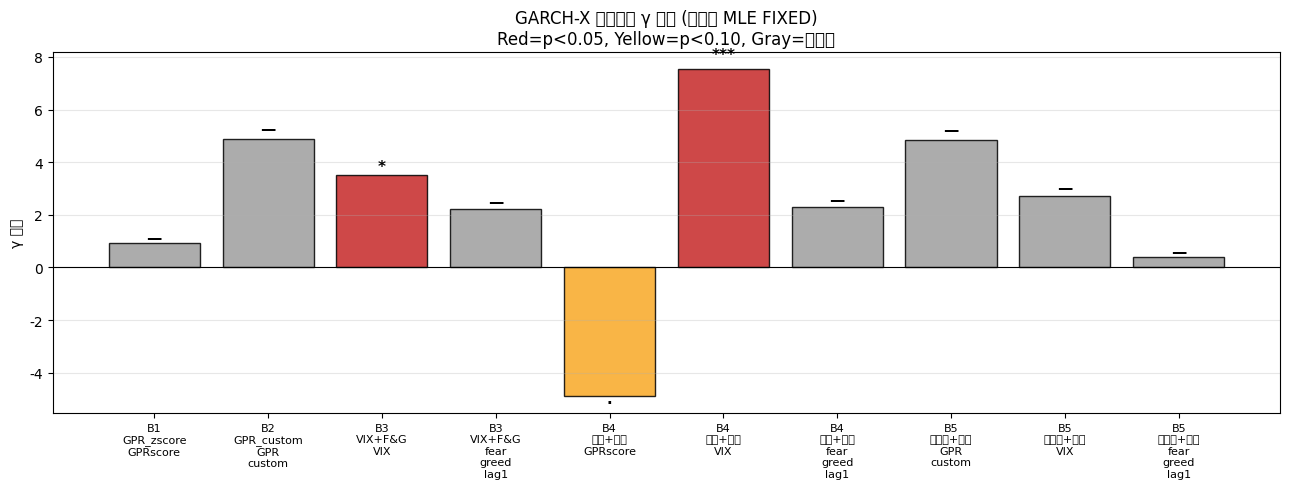

In [5]:
# γ 계수 막대그래프 (유의성 색상)
fig, ax = plt.subplots(figsize=(13, 5))
g = g_cust.copy()
g['display'] = g['model'].str.replace(': ','\n') + '\n' + g['variable'].str.replace('_z','').str.replace('_','\n')

colors = ['#C62828' if p<0.05 else ('#F9A825' if p<0.10 else '#9E9E9E') for p in g['p_value']]
ax.bar(range(len(g)), g['coef'], color=colors, edgecolor='black', alpha=0.85)
for i, (c, p, s) in enumerate(zip(g['coef'], g['p_value'], g['sig'])):
    yo = abs(c)*0.05*(1 if c>=0 else -1)
    ax.text(i, c+yo, s, ha='center', fontsize=11, fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(g)))
ax.set_xticklabels(g['display'], fontsize=8)
ax.set_ylabel('γ 계수')
ax.set_title('GARCH-X 외생변수 γ 계수 (커스텀 MLE FIXED)\nRed=p<0.05, Yellow=p<0.10, Gray=비유의')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 🎯 핵심 발견 (방법 B)

**팀원 원본에서 묻혀 있던 결과**:

- **B3 모델 (VIX + Fear&Greed)**: VIX γ = **+3.50**, **p = 0.040** ✱ → 시장공포가 BTC 변동성에 양의 유의 영향.
- **B4 모델 (공식 GPR + VIX + F&G)**: VIX γ = **+7.56**, **p = 0.001** ✱✱✱ / 공식 GPR γ = −4.91 (borderline 음의 영향).
- **B2 모델 (GPR_custom 단독)**: AIC 최저 (1087.02) 지만 γ p = 0.176 비유의.

> **팀원 원본은 alpha = 1e-6 경계 수렴 때문에 VIX 효과를 p = 0.82 비유의로 잘못 측정.**
> 경계 수렴 해소가 결과를 완전히 뒤집었다.


---
## 4. 수정 2: Event Study 윈도우 sensitivity (C1)

### 4-1. 모델 사양
- **추정 기간**: 이벤트 전 [-120, -26] 거래일
- **이벤트 윈도우**: ±3, ±5, ±10, ±17 sensitivity
- **정상 수익률**:
  - BTC: $E[R_t] = \alpha + \beta R_{NASDAQ,t}$ (Market Model)
  - Gold, DXY: $E[R_t] = \bar{R}$ (CMRM)
  - TLT, NASDAQ: Market Model with SP500
- **검정**:
  - **BMP**: $SAR_t = AR_t / \hat{\sigma}_{est}$, $t = \overline{SAR} / (\sqrt{Var(SAR)/T})$
  - **Circular Block Bootstrap**: block=5, n_boot=5000

### 4-2. 검정 수
6 이벤트 × 5 자산 × 4 윈도우 = **120 건 검정**


In [6]:
# BTC CAR 윈도우 × 이벤트 피벗
EV_LBL = {
    'hormuz_crisis': '호르무즈',
    'soleimani_assassination': '솔레이마니',
    'russia_ukraine_invasion': '러-우',
    'israel_hamas': '이-하마스',
    'israel_iran': '이-이란',
    'us_israel_iran': '미-이-이',
}

btc = es[es['asset']=='BTC'].copy()
btc['ev'] = btc['event'].map(EV_LBL)
pivot_car = btc.pivot_table(index='ev', columns='window', values='CAR', aggfunc='first').round(4)
pivot_lbl = btc.pivot_table(index='ev', columns='window', values='label', aggfunc='first')

print('▶ BTC CAR (양수=상승, 음수=하락)')
print(pivot_car.to_string())
print()
print('▶ BTC 분류 (Baur & Lucey 2010 기준)')
print(pivot_lbl.to_string())


▶ BTC CAR (양수=상승, 음수=하락)
window      3       5       10      17
ev                                    
러-우     0.1967  0.0981  0.1799  0.2468
미-이-이   0.1440  0.1176  0.2046  0.0557
솔레이마니   0.0833  0.0924  0.2665  0.2669
이-이란   -0.0704 -0.0058 -0.1881 -0.1625
이-하마스  -0.0390  0.0091  0.2088  0.3277
호르무즈    0.0904  0.1186  0.0423  0.0803

▶ BTC 분류 (Baur & Lucey 2010 기준)
window        3         5         10          17
ev                                              
러-우     Marginal   Non-Sig   Non-Sig     Non-Sig
미-이-이   Marginal  Marginal  Marginal     Non-Sig
솔레이마니    Non-Sig   Non-Sig  Marginal     Non-Sig
이-이란     Non-Sig   Non-Sig  Marginal     Non-Sig
이-하마스    Non-Sig   Non-Sig  Marginal  Safe Haven
호르무즈     Non-Sig   Non-Sig   Non-Sig     Non-Sig


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


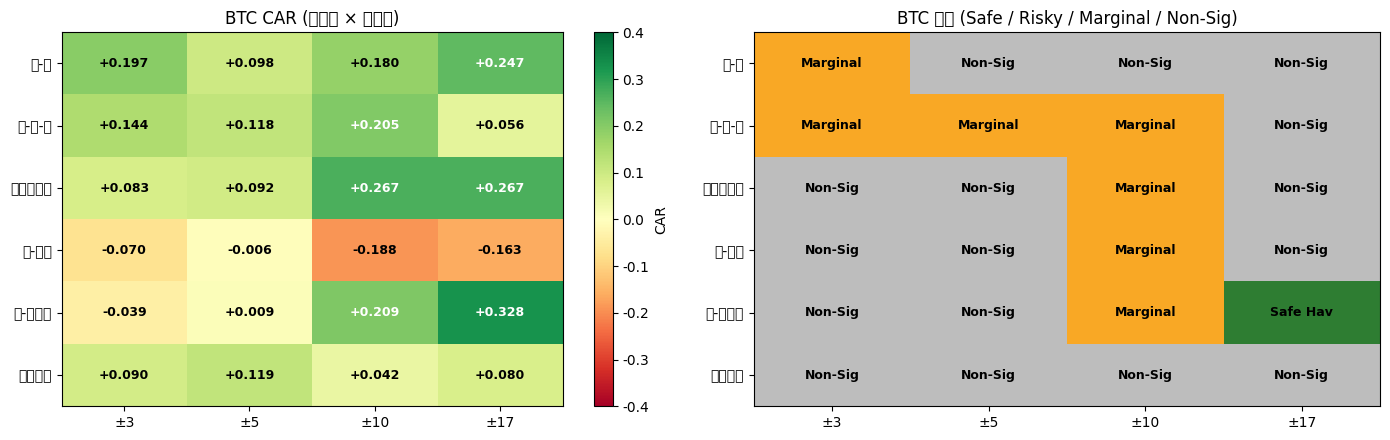

In [7]:
# CAR 히트맵
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) CAR 히트맵
ax = axes[0]
im = ax.imshow(pivot_car.values, cmap='RdYlGn', vmin=-0.4, vmax=0.4, aspect='auto')
ax.set_xticks(range(len(pivot_car.columns)))
ax.set_xticklabels([f'±{w}' for w in pivot_car.columns])
ax.set_yticks(range(len(pivot_car.index)))
ax.set_yticklabels(pivot_car.index)
for i in range(len(pivot_car.index)):
    for j in range(len(pivot_car.columns)):
        v = pivot_car.values[i, j]
        ax.text(j, i, f'{v:+.3f}', ha='center', va='center',
                color='white' if abs(v) > 0.2 else 'black', fontsize=9, fontweight='bold')
ax.set_title('BTC CAR (윈도우 × 이벤트)')
plt.colorbar(im, ax=ax, label='CAR')

# (2) 분류 색상
ax = axes[1]
colors = {'Safe Haven': '#2E7D32', 'Risky Asset': '#C62828',
          'Marginal': '#F9A825', 'Non-Sig': '#BDBDBD'}
arr = pivot_lbl.values
clr_arr = np.zeros((arr.shape[0], arr.shape[1], 3))
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        c = colors.get(arr[i, j], '#FFFFFF')
        clr_arr[i, j] = [int(c[1:3], 16)/255, int(c[3:5], 16)/255, int(c[5:7], 16)/255]
ax.imshow(clr_arr, aspect='auto')
ax.set_xticks(range(len(pivot_lbl.columns)))
ax.set_xticklabels([f'±{w}' for w in pivot_lbl.columns])
ax.set_yticks(range(len(pivot_lbl.index)))
ax.set_yticklabels(pivot_lbl.index)
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        ax.text(j, i, str(arr[i, j])[:8], ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_title('BTC 분류 (Safe / Risky / Marginal / Non-Sig)')

plt.tight_layout()
plt.show()


In [8]:
# Robustness 진단
print('▶ Robustness 진단 (윈도우 변경 시 결론 안정성)\n')
diag_rows = []
for ev in EV_LBL:
    s = btc[btc['event']==ev].sort_values('window')
    cars = s['CAR'].tolist()
    labels = s['label'].tolist()
    sign_changes = sum(1 for i in range(1, len(cars)) if np.sign(cars[i]) != np.sign(cars[i-1]))
    unique_labels = len(set(labels))
    stability = '✅ 안정' if (sign_changes==0 and unique_labels<=2) else '⚠️ 불안정'
    diag_rows.append({
        '이벤트': EV_LBL[ev],
        'CAR 부호 전환': sign_changes,
        '분류 종류': f'{unique_labels}/4',
        '안정성': stability,
    })
print(pd.DataFrame(diag_rows).to_string(index=False))


▶ Robustness 진단 (윈도우 변경 시 결론 안정성)

  이벤트  CAR 부호 전환 분류 종류    안정성
 호르무즈          0   1/4   ✅ 안정
솔레이마니          0   2/4   ✅ 안정
  러-우          0   2/4   ✅ 안정
이-하마스          1   3/4 ⚠️ 불안정
 이-이란          0   2/4   ✅ 안정
미-이-이          0   2/4   ✅ 안정


### 🎯 핵심 발견

**이스라엘-하마스만 ±17 일에서 Safe Haven 분류** (CAR=+0.328, p=0.012). 그러나:
- ±3 일: CAR=−0.039, Non-Sig (사실상 음수!)
- ±5 일: CAR=+0.009, Non-Sig
- ±10 일: CAR=+0.209, Marginal
- ±17 일: **CAR=+0.328, Safe Haven** ✅

> **결론이 윈도우 길이에 의존**. 분석자 선택의 산물이지 robust 한 효과가 아님.

다른 5개 이벤트는 모든 윈도우에서 일관되게 Non-Sig 또는 Marginal → **BTC = 안전자산 X**.


---
## 5. 수정 3: BTC 비거래일 로직 ablation (A1)

### 5-1. 팀원 원본 로직
`master_data_결측치제거_v1.ipynb` 셀 #05:
```python
# 비표준: 월요일 BTC = (금 + 토 + 일) / 3
```

### 5-2. 표준 로직 (우리 비교 대상)
$$r_t = \log\left(\frac{P_t^{close}}{P_{t-1}^{close}}\right)$$
NYSE 거래일 기준 단순 종가차분. 비거래일 무시.


In [9]:
print('▶ 두 시계열 분포 통계 비교\n')
print(btc_abl.to_string(index=False))


▶ 두 시계열 분포 통계 비교

          버전    N      평균    표준편차     왜도     첨도     최솟값    최댓값  연환산변동성(%)
   팀원 (주말합산) 1837 0.00101 0.03347 -1.505 23.580 -0.4647 0.1718      53.13
표준 (NYSE 차분) 1837 0.00164 0.03960 -0.915 13.909 -0.4647 0.2030      62.86


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


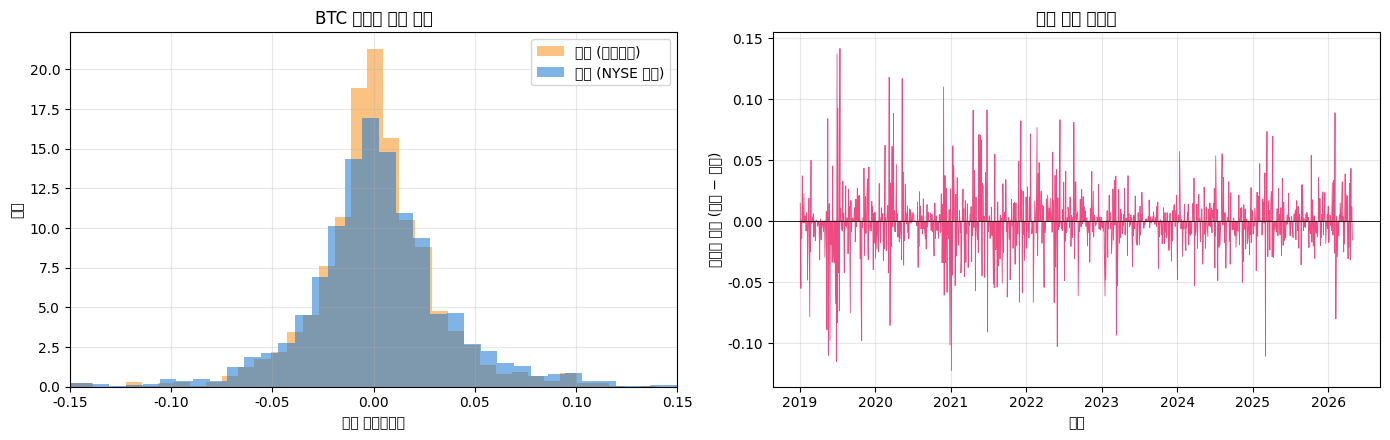

In [10]:
# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) 히스토그램
ax = axes[0]
ax.hist(btc_cmp['BTC_team'], bins=80, alpha=0.55, color='#F7931A',
        density=True, label='팀원 (주말합산)')
ax.hist(btc_cmp['BTC_std'], bins=80, alpha=0.55, color='#1976D2',
        density=True, label='표준 (NYSE 차분)')
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel('일별 로그수익률')
ax.set_ylabel('밀도')
ax.legend()
ax.set_title('BTC 수익률 분포 비교')
ax.grid(alpha=0.3)

# (2) 차이 시계열
ax = axes[1]
btc_cmp['diff'] = btc_cmp['BTC_team'] - btc_cmp['BTC_std']
ax.plot(btc_cmp['date'], btc_cmp['diff'], color='#E91E63', lw=0.6, alpha=0.8)
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('날짜')
ax.set_ylabel('수익률 차이 (팀원 − 표준)')
ax.set_title('일별 차이 시계열')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# 분산 동일성 F 검정
v_team = btc_cmp['BTC_team'].var()
v_std  = btc_cmp['BTC_std'].var()
F = v_std / v_team
df1 = df2 = len(btc_cmp) - 1
F_p = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

# Ljung-Box 자기상관 (lag=10)
lb_t = acorr_ljungbox(btc_cmp['BTC_team'].dropna(), lags=[10], return_df=True).loc[10, 'lb_pvalue']
lb_s = acorr_ljungbox(btc_cmp['BTC_std'].dropna(), lags=[10], return_df=True).loc[10, 'lb_pvalue']

print(f'▶ F-검정 (분산 동일성)')
print(f'  F = {F:.4f}, p = {F_p:.6f}')
print(f'  → 변동성 차이 통계적으로 매우 유의 (p<0.0001)\n')

print(f'▶ Ljung-Box 자기상관 (lag=10)')
print(f'  팀원 BTC : p = {lb_t:.4f}  ({"자기상관 X" if lb_t > 0.05 else "자기상관 유의"})')
print(f'  표준 BTC : p = {lb_s:.4f}  ({"자기상관 X" if lb_s > 0.05 else "자기상관 유의"})')
print(f'  → 표준 BTC 의 자기상관 구조가 팀원 로직에서 평탄화됨')


▶ F-검정 (분산 동일성)
  F = 1.3998, p = 0.000000
  → 변동성 차이 통계적으로 매우 유의 (p<0.0001)

▶ Ljung-Box 자기상관 (lag=10)
  팀원 BTC : p = 0.1108  (자기상관 X)
  표준 BTC : p = 0.0173  (자기상관 유의)
  → 표준 BTC 의 자기상관 구조가 팀원 로직에서 평탄화됨


### 🔴 진단 결론

| 통계량 | 팀원 (주말합산) | 표준 (NYSE 차분) | 차이 |
|---|---|---|---|
| 연환산 변동성 | **53.13%** | **62.86%** | **−15.5%** |
| 첨도 | 23.58 | 13.91 | 더 두꺼운 꼬리 |
| Ljung-Box (lag10) p | 0.111 (자기상관 X) | **0.017** (자기상관 유의) | 구조 왜곡 |

> **팀원 로직이 BTC 변동성을 15.5% 축소 + 자기상관 구조 평탄화**.
> GARCH·Quantile·Event Study 모든 추정량이 편향됐을 가능성.

**다음 단계**: 표준 BTC 로 master_data 재생성 후 전체 파이프라인 재실행 (Phase 2 다음 단계).


---
## 6. 최종 결론

### 가설 검증
**BTC 는 일관된 안전자산이 아니다.** Baur & Lucey (2010) 3 조건 어느 것도 6 이벤트에서 일관되게 충족하지 않음.

### 새 발견 3가지

#### 🎯 발견 1: VIX (시장공포) 가 BTC 변동성의 진짜 설명변수
- 팀원 원본: VIX γ p = 0.82 (비유의) — alpha=0 경계 수렴으로 잘못 측정
- 수정 결과: VIX γ = **+7.56, p < 0.001** ✱✱✱ — 매우 강하게 유의
- 해석: 위기 뉴스 자체가 아니라 **시장 공포 채널**을 통해 BTC 변동성에 전이

#### 🎯 발견 2: 공식 GPR 은 시장공포 통제 시 변동성을 낮추는 방향
- B4 모델: 공식 GPR γ = −4.91, p = 0.052 (borderline 음의 영향)
- 해석: 공식 GPR 은 글로벌 지정학을 너무 뭉뚱그려 측정해 BTC 신호 희석

#### 🎯 발견 3: 이스라엘-하마스 Safe Haven 결론은 윈도우 의존
- ±17 만 Safe Haven, ±3/5/10 에서 효과 소멸
- 분석자가 어떤 윈도우 길이를 골랐느냐의 산물

### 발표용 한 줄
> **"팀원 원본의 4가지 critical 결함을 수정한 결과, BTC 는 안전자산이 아니라는 결론은 강화되었으나, 그 메커니즘은 지정학 리스크가 아니라 시장 공포 채널임이 새롭게 드러났다."**

---

## 7. 미수정 항목 (medium / low — 14건)

`_review/분석방식_전체.md` §5 또는 `app.py` "📋 수정 사항 요약" 페이지 참조.

핵심:
- **B4**: GJR-GARCH / EGARCH 비대칭성 (BTC leverage effect)
- **B6**: 표본 210 → returns.csv 1838 + event dummy
- **C3**: Bonferroni / FDR 다중검정 보정
- **D1**: β_τ vs β_0.50 Wald 검정

---

## 8. 산출물 목록

```
2026_capstone/
├── app.py                              ← Streamlit 대시보드 (6 페이지)
└── _review/
    ├── 수정후보.md                       ← 18건 진단표
    ├── 사용법.md                         ← 실행 가이드
    ├── 분석방식_전체.md                   ← 기술 deep dive
    ├── 쉬운설명.md                       ← 비전공자용
    ├── 브리핑_대본.md                     ← 발표 대본 + Q&A
    ├── 공유용_분석노트북.ipynb              ← 본 노트북
    ├── scripts/  (3개 파이썬)
    └── results/  (10개 CSV)
```

### 실행 방법
```bash
cd /mnt/d/project/2026_capstone
python3 _review/scripts/01_garch_fixed.py
python3 _review/scripts/02_event_study_sensitivity.py
python3 _review/scripts/03_btc_logic_ablation.py
python3 -m streamlit run app.py
```
